# Gemma 4 Architecture Explainer - notebook companion

This notebook is the technical companion to the Substack-style article. It keeps the same idea, but adds runnable calculations for the places where the architecture becomes easier to understand with numbers:

- model-family table
- dense vs MoE active-parameter ratio
- attention score growth
- rough 31B KV-cache estimate
- image token-budget math

The diagrams are embedded as SVG images, so the notebook remains readable even before running the code.

In [1]:
import math
import pandas as pd
import matplotlib.pyplot as plt

models = pd.DataFrame([
    {"model": "Gemma 4 E2B", "type": "Dense", "total_params_B": 5.1, "effective_or_active_B": 2.3, "layers": 35, "context_tokens": 128_000, "sliding_window": 512, "modalities": "text, image, audio"},
    {"model": "Gemma 4 E4B", "type": "Dense", "total_params_B": 8.0, "effective_or_active_B": 4.5, "layers": 42, "context_tokens": 128_000, "sliding_window": 512, "modalities": "text, image, audio"},
    {"model": "Gemma 4 26B A4B", "type": "MoE", "total_params_B": 25.2, "effective_or_active_B": 3.8, "layers": 30, "context_tokens": 256_000, "sliding_window": 1024, "modalities": "text, image"},
    {"model": "Gemma 4 31B", "type": "Dense", "total_params_B": 30.7, "effective_or_active_B": 30.7, "layers": 60, "context_tokens": 256_000, "sliding_window": 1024, "modalities": "text, image"},
])
models

,model,type,total_params_B,effective_or_active_B,layers,context_tokens,sliding_window,modalities
0,Gemma 4 E2B,Dense,5.1,2.3,35,128000,512,"text, image, audio"
1,Gemma 4 E4B,Dense,8.0,4.5,42,128000,512,"text, image, audio"
2,Gemma 4 26B A4B,MoE,25.2,3.8,30,256000,1024,"text, image"
3,Gemma 4 31B,Dense,30.7,30.7,60,256000,1024,"text, image"


## Decoder block sketch

In a decoder-only transformer, the residual stream is updated by two main edits: an attention edit and a feed-forward edit. Gemma 4 keeps that overall shape, while adding details such as Q/K/V normalization, local/global attention, RoPE variants, and MoE routing in the 26B A4B model.

## Calculation 1 - Dense vs MoE active parameters

The 26B A4B checkpoint stores many more parameters than it activates for one token. The important number is not only total parameters; it is the active fraction.

In [2]:
total = 25.2
active = 3.8
active_pct = active / total * 100
print(f"Gemma 4 26B A4B active fraction = {active:.1f}B / {total:.1f}B = {active_pct:.1f}%")

Gemma 4 26B A4B active fraction = 3.8B / 25.2B = 15.1%


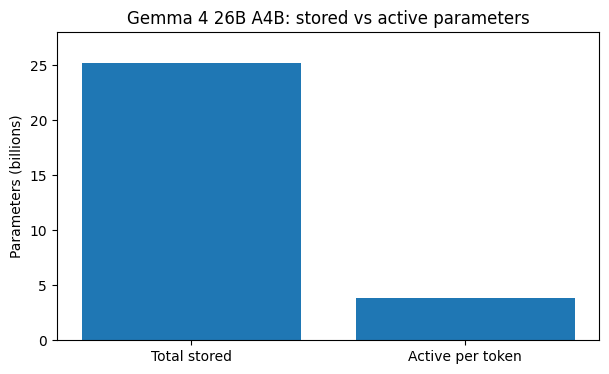

In [3]:
plt.figure(figsize=(7, 4))
plt.bar(["Total stored", "Active per token"], [total, active])
plt.ylabel("Parameters (billions)")
plt.title("Gemma 4 26B A4B: stored vs active parameters")
plt.ylim(0, 28)
plt.show()

## Calculation 2 - Full attention vs sliding attention

Full attention grows as `N^2`. Sliding-window attention grows as `N * W`, where `W` is the local window. For a 256K context and a 1,024-token window, the reduction in score entries for that layer is exactly 256x.

In [4]:
N = 262_144
W = 1_024
full_scores = N * N
sliding_scores = N * W
ratio = full_scores / sliding_scores
print(f"Full attention scores per head: {full_scores:,}")
print(f"Sliding-window scores per head: {sliding_scores:,}")
print(f"Reduction: {ratio:.0f}x")

Full attention scores per head: 68,719,476,736
Sliding-window scores per head: 268,435,456
Reduction: 256x


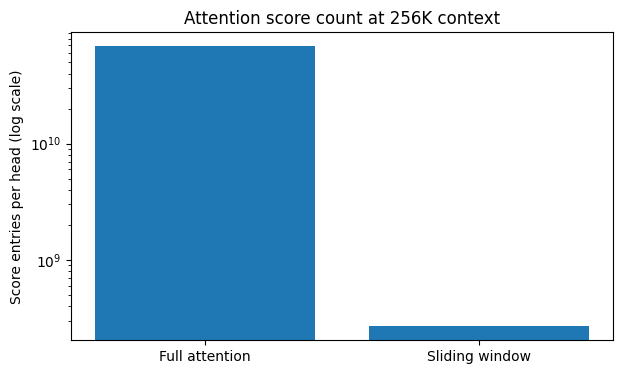

In [5]:
plt.figure(figsize=(7, 4))
plt.bar(["Full attention", "Sliding window"], [full_scores, sliding_scores])
plt.yscale("log")
plt.ylabel("Score entries per head (log scale)")
plt.title("Attention score count at 256K context")
plt.show()

## Calculation 3 - A rough KV-cache estimate for 31B

This is a teaching calculation using public config values for the 31B model. It assumes BF16 cache values, batch size 1, 50 sliding layers, 10 global layers, and compact rolling storage for local layers.

Real engines can differ because of paged attention, quantized KV cache, padding, batch size, and allocator overhead.

In [6]:
N = 262_144
W = 1_024
bf16_bytes = 2
local_layers = 50
global_layers = 10
local_kv_heads = 16
local_head_dim = 256
global_kv_heads = 4
global_head_dim = 512

bytes_local_per_token_layer = 2 * local_kv_heads * local_head_dim * bf16_bytes
bytes_global_per_token_layer = 2 * global_kv_heads * global_head_dim * bf16_bytes

naive_full_all = N * 60 * bytes_local_per_token_layer
local_cache = W * local_layers * bytes_local_per_token_layer
global_cache = N * global_layers * bytes_global_per_token_layer
total_hybrid = local_cache + global_cache

def gib(x):
    return x / (1024**3)

kv_table = pd.DataFrame([
    {"case": "Naive all layers full", "GiB": gib(naive_full_all)},
    {"case": "Hybrid local windows", "GiB": gib(local_cache)},
    {"case": "Hybrid global layers", "GiB": gib(global_cache)},
    {"case": "Hybrid total", "GiB": gib(total_hybrid)},
])
kv_table

,case,GiB
0,Naive all layers full,240.00000
1,Hybrid local windows,0.78125
2,Hybrid global layers,20.00000
3,Hybrid total,20.78125


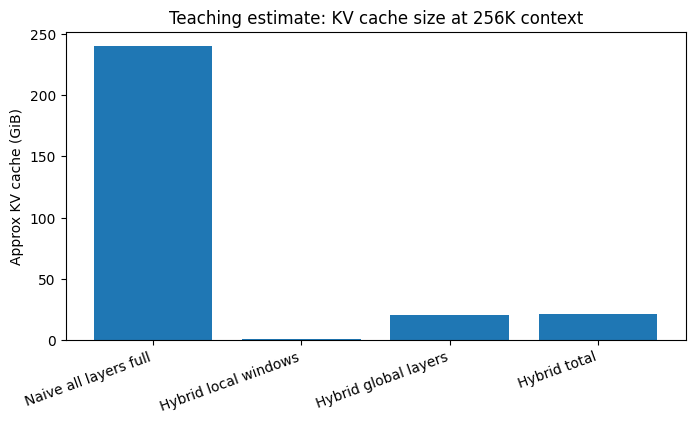

In [7]:
plt.figure(figsize=(8, 4))
plt.bar(kv_table["case"], kv_table["GiB"])
plt.ylabel("Approx KV cache (GiB)")
plt.title("Teaching estimate: KV cache size at 256K context")
plt.xticks(rotation=20, ha="right")
plt.show()

## Calculation 4 - Vision token budget

Gemma 4's default visual budget is 280 soft tokens. Because the encoder pools 3 by 3 patch groups, the pre-pooling patch count is 9 times the final soft-token count. A 60 by 42 patch grid gives an exact 960 by 672 pixel example.

In [8]:
budgets = [70, 140, 280, 560, 1120]
vision = []
for budget in budgets:
    patches = budget * 9
    pixel_area = patches * 16 * 16
    vision.append({"soft_tokens": budget, "pre_pool_patches": patches, "approx_pixel_area": pixel_area})
vision_df = pd.DataFrame(vision)
vision_df

,soft_tokens,pre_pool_patches,approx_pixel_area
0,70,630,161280
1,140,1260,322560
2,280,2520,645120
3,560,5040,1290240
4,1120,10080,2580480


In [9]:
soft_tokens = 280
patches_before_pooling = soft_tokens * 9
patch_grid_w, patch_grid_h = 60, 42
image_w, image_h = patch_grid_w * 16, patch_grid_h * 16
pooled_w, pooled_h = patch_grid_w // 3, patch_grid_h // 3
print(f"soft tokens: {soft_tokens}")
print(f"pre-pooling patches: {patches_before_pooling}")
print(f"example image: {image_w} x {image_h} = {image_w*image_h:,} pixels")
print(f"pooled token grid: {pooled_w} x {pooled_h} = {pooled_w*pooled_h} tokens")

soft tokens: 280
pre-pooling patches: 2520
example image: 960 x 672 = 645,120 pixels
pooled token grid: 20 x 14 = 280 tokens


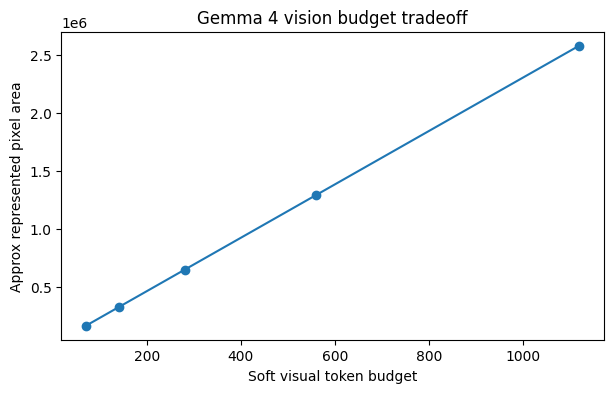

In [10]:
plt.figure(figsize=(7, 4))
plt.plot(vision_df["soft_tokens"], vision_df["approx_pixel_area"], marker="o")
plt.xlabel("Soft visual token budget")
plt.ylabel("Approx represented pixel area")
plt.title("Gemma 4 vision budget tradeoff")
plt.show()

## RoPE sketch

Rotary embeddings encode position by rotating parts of query/key vectors. In a long-context model, this matters because the attention score is a comparison between positions, not just between token identities.

## Tokenization and vocabulary size

Gemma 4 uses a SentencePiece-style BPE tokenizer with a vocabulary around 262,144 tokens. Larger vocabularies mean more symbols per slot and typically fewer tokens per character of text, which improves throughput but grows the embedding matrix. The rough heuristic below treats average token length as proportional to `log2(vocab_size)` - this is a teaching approximation, not a measured statistic. See the [SentencePiece paper](https://arxiv.org/abs/1808.06226) and the [Gemma model card](https://ai.google.dev/gemma/docs/core/model_card_4) for the actual tokenizer spec.


In [ ]:
import math
import matplotlib.pyplot as plt

vocab_sizes = [32_000, 50_000, 128_000, 262_144]
# Heuristic: average token length (in chars) scales with log2(vocab).
# Calibrate so vocab=32k gives ~3.8 chars/token (a common empirical value).
calib = 3.8 / math.log2(32_000)
avg_token_chars = [calib * math.log2(v) for v in vocab_sizes]
tokens_per_char = [1.0 / c for c in avg_token_chars]

for v, c, t in zip(vocab_sizes, avg_token_chars, tokens_per_char):
    print(f'vocab={v:>7,}  avg_chars/token={c:.2f}  tokens/char={t:.3f}')

plt.figure(figsize=(7, 4))
plt.bar([f'{v//1000}k' for v in vocab_sizes], tokens_per_char,
        color=['#9ecae1', '#6baed6', '#3182bd', '#08519c'])
plt.ylabel('tokens per character (lower is better)')
plt.xlabel('vocabulary size')
plt.title('Tokenizer efficiency vs vocab size (heuristic)')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


## Grouped-Query Attention (GQA)

GQA sits between full multi-head attention (each query head gets its own key/value head) and multi-query attention (all query heads share one KV head). Gemma 4 uses GQA with different group sizes on local vs global layers. The KV cache memory per token is proportional to `n_kv_heads * head_dim * 2 * dtype_bytes`, so cutting KV heads is the biggest lever on long-context memory. See [Ainslie et al., GQA](https://arxiv.org/abs/2305.13245).


In [ ]:
import matplotlib.pyplot as plt

# Gemma 4 31B: head_dim = 128, bf16 = 2 bytes. KV per token per layer = 2 * n_kv * 128 * 2 bytes.
head_dim = 128
bytes_per_elem = 2  # bf16

def kv_per_token(n_kv_heads):
    # 2x because both K and V are stored
    return 2 * n_kv_heads * head_dim * bytes_per_elem

configs = [
    ('Local (32Q, 16KV)', 16),
    ('Global 31B (32Q, 4KV)', 4),
    ('Hypothetical MHA (32KV)', 32),
]
labels = [c[0] for c in configs]
bytes_vals = [kv_per_token(c[1]) for c in configs]

for lbl, b in zip(labels, bytes_vals):
    print(f'{lbl}: {b} bytes/token  ({b/1024:.2f} KiB)')

plt.figure(figsize=(8, 4))
plt.bar(labels, bytes_vals, color=['#74c476', '#31a354', '#de2d26'])
plt.ylabel('KV cache bytes per token per layer')
plt.title('KV cache footprint by attention config (head_dim=128, bf16)')
plt.xticks(rotation=15, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


## Layer pattern for 31B

Gemma 4 31B interleaves local (sliding-window) and global (full) attention in a 5:1 ratio across 60 decoder blocks - 50 local layers plus 10 global layers. At 256K context, the global layers dominate the KV cache even though they are a minority of layers, because they attend over the full sequence while the local layers only cache a sliding window. See the [31B config.json](https://huggingface.co/google/gemma-4-31B/blob/main/config.json).


In [ ]:
import matplotlib.pyplot as plt

pattern = (['local'] * 5 + ['global']) * 10  # 5:1 ratio, 60 layers total
assert len(pattern) == 60
n_local = pattern.count('local')
n_global = pattern.count('global')
print(f'Total layers: {len(pattern)}  local: {n_local}  global: {n_global}')

# KV cache at 256K context, bf16, head_dim=128
N = 256_000
W = 1_024           # sliding window for local layers
head_dim = 128
bytes_per_elem = 2
kv_local_heads = 16
kv_global_heads = 4

def layer_bytes(n_kv, tokens):
    return 2 * n_kv * head_dim * bytes_per_elem * tokens

local_total = n_local * layer_bytes(kv_local_heads, W)
global_total = n_global * layer_bytes(kv_global_heads, N)
total = local_total + global_total

print(f'Local layers KV cache:  {local_total/1024**3:6.2f} GiB  ({local_total/total*100:4.1f}%)')
print(f'Global layers KV cache: {global_total/1024**3:6.2f} GiB  ({global_total/total*100:4.1f}%)')
print(f'Total KV cache:         {total/1024**3:6.2f} GiB')

plt.figure(figsize=(6, 6))
plt.pie([local_total, global_total],
        labels=[f'Local ({n_local} layers, W={W})',
                f'Global ({n_global} layers, N={N})'],
        autopct='%1.1f%%',
        colors=['#9ecae1', '#08519c'],
        startangle=90)
plt.title('KV cache memory share by layer type (31B, 256K ctx)')
plt.tight_layout()
plt.show()


## Per-Layer Embeddings (PLE) detail

Per-Layer Embeddings give each transformer block a small learned embedding that is mixed into the residual stream. A common variance-preserving trick is to combine the residual `a` with the PLE contribution `b` as `(a + b) / sqrt(2)`: if `a` and `b` are uncorrelated with unit variance, the sum has variance 2 and dividing by `sqrt(2)` restores unit variance. The snippet below verifies this numerically.


In [ ]:
import numpy as np

rng = np.random.default_rng(0)
n = 10_000
a = rng.standard_normal(n)
b = rng.standard_normal(n)

sum_raw = a + b
sum_scaled = (a + b) / np.sqrt(2)

print(f'var(a)         = {a.var():.4f}')
print(f'var(b)         = {b.var():.4f}')
print(f'var(a+b)       = {sum_raw.var():.4f}   (expected ~2.0)')
print(f'var((a+b)/sqrt 2) = {sum_scaled.var():.4f}   (expected ~1.0)')

import matplotlib.pyplot as plt
plt.figure(figsize=(7, 4))
plt.hist(sum_raw, bins=60, alpha=0.5, label='a + b  (var approx 2)', color='#de2d26')
plt.hist(sum_scaled, bins=60, alpha=0.5, label='(a+b)/sqrt 2  (var approx 1)', color='#31a354')
plt.legend()
plt.title('Variance preservation via 1/sqrt(2) scaling')
plt.xlabel('value')
plt.ylabel('count')
plt.tight_layout()
plt.show()


## Quantization memory across the family

Gemma 4 is shipped in several weight precisions. BF16 is the reference, SFP8 is a selective 8-bit quantization that keeps sensitive tensors in higher precision, and Q4 is 4-bit weight-only quantization. The table below uses the approximate weight footprints listed in the article; activations and KV cache are not included. See the [Gemma model card](https://ai.google.dev/gemma/docs/core/model_card_4) for the authoritative numbers.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

quant = pd.DataFrame({
    'model': ['E2B', 'E4B', '26B A4B', '31B'],
    'BF16_GB': [10.0, 16.0, 50.0, 60.0],
    'SFP8_GB': [5.0, 8.0, 25.0, 30.0],
    'Q4_GB':   [3.2, 5.0, 15.6, 17.4],
})
print(quant.to_string(index=False))

x = np.arange(len(quant))
w = 0.26

plt.figure(figsize=(9, 4.5))
plt.bar(x - w, quant['BF16_GB'], width=w, label='BF16', color='#08519c')
plt.bar(x,     quant['SFP8_GB'], width=w, label='SFP8', color='#3182bd')
plt.bar(x + w, quant['Q4_GB'],   width=w, label='Q4',   color='#9ecae1')
plt.xticks(x, quant['model'])
plt.ylabel('approx. weight memory (GB)')
plt.title('Gemma 4 weight footprint by precision')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


## Audio encoder path

Gemma 4 E-variants accept audio via a USM-style encoder that consumes mel spectrogram frames and emits a sequence of audio tokens merged into the same stream as text. A typical pipeline: 16 kHz raw audio is framed into 80-channel log-mel features every 10 ms (100 frames/second), then an encoder downsamples (roughly 4x) to produce audio tokens. See the [USM paper](https://arxiv.org/abs/2303.01037) for background.


In [ ]:
import matplotlib.pyplot as plt

sample_rate_hz = 16_000
frame_hop_ms = 10
frames_per_second = 1000 / frame_hop_ms  # 100 mel frames/s
downsample = 4

clip_seconds = 30
mel_frames = int(frames_per_second * clip_seconds)
audio_tokens = mel_frames // downsample

print(f'Sample rate:      {sample_rate_hz} Hz')
print(f'Mel hop:          {frame_hop_ms} ms  ->  {frames_per_second:.0f} frames/s')
print(f'30 s clip frames: {mel_frames}')
print(f'After {downsample}x downsample: {audio_tokens} audio tokens')
print(f'Equivalent token rate: {audio_tokens/clip_seconds:.1f} tokens/s of audio')

durations = [1, 5, 10, 30, 60]
tokens = [int(frames_per_second * d) // downsample for d in durations]
plt.figure(figsize=(7, 4))
plt.plot(durations, tokens, marker='o', color='#6baed6')
plt.xlabel('clip duration (seconds)')
plt.ylabel('audio tokens emitted')
plt.title('Audio tokens per clip (100 fps mel, 4x downsample)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Function-calling loop

Gemma 4 supports a simple tool-use convention: the model emits a `<tool_call>` block with JSON arguments, the runtime executes the tool and returns a `<tool_result>` block, and the model resumes generation conditioned on the result. The snippet below simulates one full turn. See the [Gemma model card](https://ai.google.dev/gemma/docs/core/model_card_4) for the official format.


In [ ]:
import json

# Fake tool registry
def get_weather(city, units='celsius'):
    return {'city': city, 'temp': 14, 'units': units, 'conditions': 'cloudy'}

TOOLS = {'get_weather': get_weather}

user_msg = 'What is the weather in Zurich right now?'
print(f'USER: {user_msg}
')

# Model turn 1: emits a tool call
model_turn_1 = (
    '<tool_call>
'
    '{"name": "get_weather", "arguments": {"city": "Zurich"}}
'
    '</tool_call>'
)
print('MODEL (turn 1):')
print(model_turn_1)
print()

# Runtime parses and executes the tool
call = json.loads(model_turn_1.split('<tool_call>')[1].split('</tool_call>')[0].strip())
result = TOOLS[call['name']](**call['arguments'])
tool_result = (
    '<tool_result>
'
    f'{json.dumps(result)}
'
    '</tool_result>'
)
print('RUNTIME:')
print(tool_result)
print()

# Model turn 2: final natural-language reply conditioned on the tool result
model_turn_2 = (
    f'It is about {result["temp"]} C and {result["conditions"]} in '
    f'{result["city"]} at the moment.'
)
print('MODEL (turn 2):')
print(model_turn_2)


## Prefill vs decode cost

During prefill the model processes the whole prompt of length `N` in one shot; the dominant compute is the matmul cost roughly `N * L * d^2` (attention/MLP projections). During decode, each new token only needs one query against the cached keys/values: the cache read scales as `N * L * d` per step while the per-step MLP work stays at `1 * L * d^2`. This is why long contexts make prefill expensive but decode step cost stays modest. See the [efficient transformers survey](https://arxiv.org/abs/2009.06732).


In [ ]:
import matplotlib.pyplot as plt

L = 60       # layers (31B)
d = 4096     # model dim (illustrative)
scale = 1e-9 # arbitrary scaling for readability

Ns = [1_000, 10_000, 100_000, 262_144]
prefill = [N * L * d * d * scale for N in Ns]
decode_cache = [N * L * d * scale for N in Ns]       # KV read per decode step
decode_mlp = [1 * L * d * d * scale for _ in Ns]     # per-step MLP (constant in N)
decode_total = [c + m for c, m in zip(decode_cache, decode_mlp)]

print(f'{"N":>8}  {"prefill":>12}  {"decode/step":>12}')
for N, p, d_ in zip(Ns, prefill, decode_total):
    print(f'{N:>8}  {p:>12.3f}  {d_:>12.5f}')

plt.figure(figsize=(8, 4.5))
plt.loglog(Ns, prefill, marker='o', label='prefill total ~ N*L*d^2', color='#de2d26')
plt.loglog(Ns, decode_total, marker='s', label='decode/step ~ N*L*d + L*d^2', color='#31a354')
plt.loglog(Ns, decode_cache, marker='^', linestyle='--', label='decode cache read ~ N*L*d', color='#6baed6')
plt.xlabel('context length N')
plt.ylabel('relative cost (arbitrary units)')
plt.title('Prefill vs decode cost scaling')
plt.legend()
plt.grid(which='both', alpha=0.3)
plt.tight_layout()
plt.show()


## Model decision tree

A quick lookup for picking a Gemma 4 checkpoint based on hardware and use case. Memory numbers refer to weights only, roughly at Q4, and assume you still have headroom for activations and KV cache. See the [Gemma model card](https://ai.google.dev/gemma/docs/core/model_card_4) for canonical guidance.

| If you need...                               | Pick           | Why                                              |
|---                                           |---             |---                                               |
| On-device (phone / laptop), multimodal       | **E2B**        | ~3 GB at Q4, text + image + audio                |
| Mid-range laptop/workstation, multimodal     | **E4B**        | ~5 GB at Q4, best E-variant quality              |
| Cheap text/vision serving at scale           | **26B A4B MoE**| 25B stored, only ~4B active per token            |
| Maximum single-model quality, one GPU class  | **31B**        | Dense 30.7B, 256K context, 60 layers             |


## Source anchors

- Google AI for Developers - Gemma 4 model card: https://ai.google.dev/gemma/docs/core/model_card_4
- Google AI for Developers - Gemma model overview: https://ai.google.dev/gemma/docs/core
- Hugging Face Transformers - Gemma 4 docs: https://github.com/huggingface/transformers/blob/main/docs/source/en/model_doc/gemma4.md
- Google vision understanding docs: https://ai.google.dev/gemma/docs/capabilities/vision
- Hugging Face 31B config: https://huggingface.co/google/gemma-4-31B/blob/main/config.json
- Keras Hub Gemma4Backbone: https://keras.io/keras_hub/api/models/gemma4/gemma4_backbone/
- Keras Hub Gemma4VisionEncoder: https://keras.io/keras_hub/api/models/gemma4/gemma4_vision_encoder/
- Transformer paper: https://arxiv.org/abs/1706.03762
- RoPE paper: https://arxiv.org/abs/2104.09864
- GQA paper: https://arxiv.org/abs/2305.13245
- MoE paper: https://arxiv.org/abs/1701.06538
